# Data Collection:

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.model_selection import train_test_split, KFold, GridSearchCV

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Importing the Dataset

In [2]:
df= pd.read_csv('/kaggle/input/datasets/dgomonov/new-york-city-airbnb-open-data/AB_NYC_2019.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


# Data Exploration:

In [3]:
df.shape

(48895, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [5]:
# Checking the Statistical info about the data
df.describe().T           # " .T " function changes the rows into columns i.e. Transposing for better readability

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


## Ensuring data completeness and accuracy

In [6]:
# Checking for Null Values
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [7]:
#Dropping the columns 'name' and 'host_name' as they are insignificant for our Data modeling
df = df.drop(columns=['name', 'host_name'])

In [8]:
# filling the two reviews with zero i.e. no review given for that particular airbnb
df.fillna({'reviews_per_month':0}, inplace=True)
df.fillna({'last_review':0}, inplace=True)

In [9]:
# Converting the "last_review" column to_datetime
df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")

df["last_review"] = df["last_review"].fillna(df["last_review"].min())

In [10]:
# Dropping rows without price
df = df[df["price"] > 0]

In [11]:
# Checking for duplicates
df.duplicated().sum()

np.int64(0)

In [12]:
# checking the null values after changes
df.isnull().sum()

id                                0
host_id                           0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

# Data Preprocessing:

## Removing outliers in pricing data

In [13]:
Q1 = np.percentile(df['price'], 25, method='midpoint')
Q3 = np.percentile(df['price'], 75, method='midpoint')
IQR = Q3 - Q1
print(IQR)

106.0


In [14]:
upper = Q3+1.5*IQR
upper_array = np.array(df['price'] >= upper)
print("Upper Bound:", upper)
print(upper_array.sum())

lower = Q1-1.5*IQR
lower_array = np.array(df['price'] <= lower)
print("Lower Bound:", lower)
print(lower_array.sum())

Upper Bound: 334.0
2977
Lower Bound: -90.0
0


In [15]:
df['price'] = np.where(df['price'] > upper, upper, df['price'])
df['price'] = np.where(df['price'] < lower, lower, df['price'])

print("Shape after Capping:", df.shape)

Shape after Capping: (48884, 14)


# Exploratory Data Analysis (EDA):

## Identifying price variations by neighborhood and room type

neighbourhood_group
Bronx             82.380734
Brooklyn         113.574720
Manhattan        164.668790
Queens            93.186904
Staten Island     94.485255
Name: price, dtype: float64 



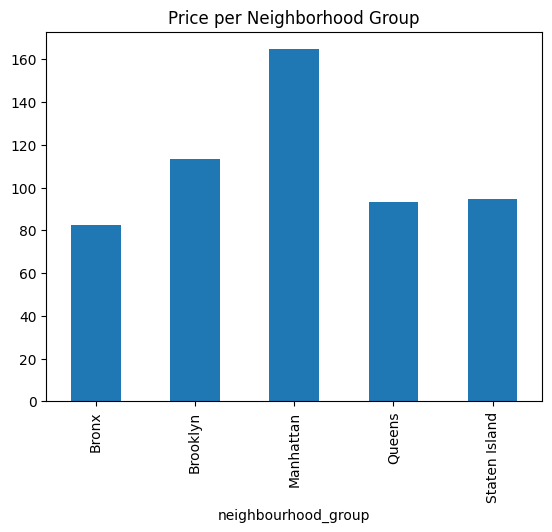

In [16]:
price_per_neighborhood_group = df.groupby("neighbourhood_group")["price"].mean()
print(price_per_neighborhood_group, '\n')

price_per_neighborhood_group.plot(kind='bar')
plt.title('Price per Neighborhood Group')
plt.show()

### Conclusion:

* Manhattan commands the highest prices by a significant margin, nearly 60% more expensive than the city-wide average — reflecting its central location, high demand, and premium real estate
* Brooklyn is the second most expensive, likely driven by its popularity among travelers seeking a more local experience while staying close to Manhattan
* Staten Island ranks third, which is somewhat surprising given its relative remoteness — this may reflect a smaller supply of listings inflating the average
* Queens is mid-range, offering a more affordable alternative with good transit access to major attractions
* The Bronx is the most affordable, making it the budget-friendly option, though lower tourism demand likely contributes to this
* There is a clear price gradient tied to proximity to central NYC and tourism demand

room_type
Entire home/apt    180.222380
Private room        82.813343
Shared room         64.614853
Name: price, dtype: float64 



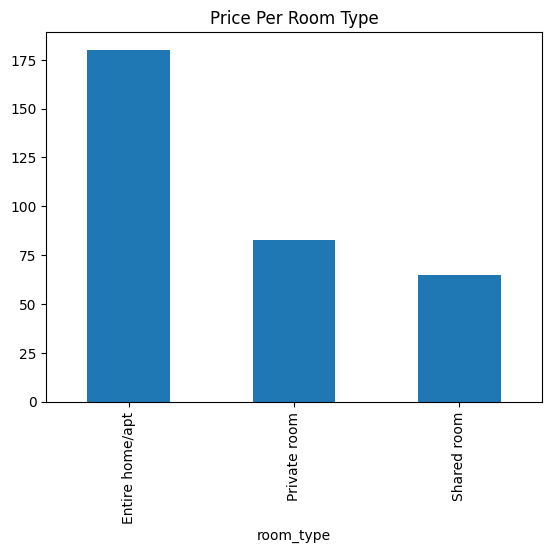

In [17]:
price_per_room_type = df.groupby("room_type")["price"].mean()
print(price_per_room_type, '\n')

price_per_room_type.plot(kind='bar')
plt.title('Price Per Room Type')
plt.show()

### Conclusion:
* Entire Home/Apt is by far the most expensive, priced more than 2x higher than a private room
* Guests pay a premium for full privacy, exclusive access to all amenities, and the feel of a standalone accommodation
* Private Rooms are mid-range, offering a balance between affordability and personal space
* These are popular among solo travelers or couples who don't mind sharing common areas with the host or other guests
* Shared Rooms are the most budget-friendly, though the price gap between shared and private rooms is relatively small (~$20)
* This Suggests that many travelers opt to upgrade to a private room for modest additional cost

## Analyzing customer reviews and host response times

In [18]:
print("── Review Statistics ──")
print(df["number_of_reviews"].describe().round(2))
 
print("\n── Avg Reviews by Neighbourhood Group ──")
print(df.groupby("neighbourhood_group")["number_of_reviews"].mean().round(2).sort_values(ascending=False))
 
print("\n── Avg Reviews by Room Type ──")
print(df.groupby("room_type")["number_of_reviews"].mean().round(2).sort_values(ascending=False))

── Review Statistics ──
count    48884.00
mean        23.27
std         44.55
min          0.00
25%          1.00
50%          5.00
75%         24.00
max        629.00
Name: number_of_reviews, dtype: float64

── Avg Reviews by Neighbourhood Group ──
neighbourhood_group
Staten Island    30.94
Queens           27.70
Bronx            25.98
Brooklyn         24.20
Manhattan        20.99
Name: number_of_reviews, dtype: float64

── Avg Reviews by Room Type ──
room_type
Private room       24.10
Entire home/apt    22.84
Shared room        16.62
Name: number_of_reviews, dtype: float64


### Conclusion:
* Review volume is inversely related to price
* More affordable boroughs and room types tend to attract more bookings and thus more reviews
* Indicating that budget-friendly listings see higher guest engagement overall

In [19]:
df["days_since_last_review"] = (pd.Timestamp("2019-07-01") - df["last_review"]).dt.days
 
df["response_band"] = pd.cut(
    df["days_since_last_review"],
    bins=[0, 30, 90, 180, 365, np.inf],
    labels=["< 1 month", "1–3 months", "3–6 months", "6–12 months", "> 1 year"]
)
 
print("\n── Host Response Time Bands ──")
print(df["response_band"].value_counts().sort_index())
 
print("\n── Avg Reviews per Month by Response Band ──")
print(df.groupby("response_band", observed=True)["reviews_per_month"].mean().round(2))


── Host Response Time Bands ──
response_band
< 1 month      12596
1–3 months      5105
3–6 months      2378
6–12 months     4447
> 1 year       19633
Name: count, dtype: int64

── Avg Reviews per Month by Response Band ──
response_band
< 1 month      2.24
1–3 months     0.97
3–6 months     0.61
6–12 months    0.45
> 1 year       0.09
Name: reviews_per_month, dtype: float64


### Conclusion:
* Listing recency is a strong proxy for booking demand
* Recently reviewed listings are significantly more active
* As the highly active listings likely command better pricing power

## Visualizing price distributions across different locations

neighbourhood
Fort Wadsworth        334.000000
Woodrow               334.000000
Neponsit              269.333333
Tribeca               260.548023
Willowbrook           249.000000
NoHo                  243.243590
Flatiron District     233.687500
Midtown               220.771521
West Village          214.947917
Breezy Point          213.333333
SoHo                  207.005587
Financial District    202.525538
Theater District      201.555556
Chelsea               201.543576
Greenwich Village     199.908163
Name: price, dtype: float64 



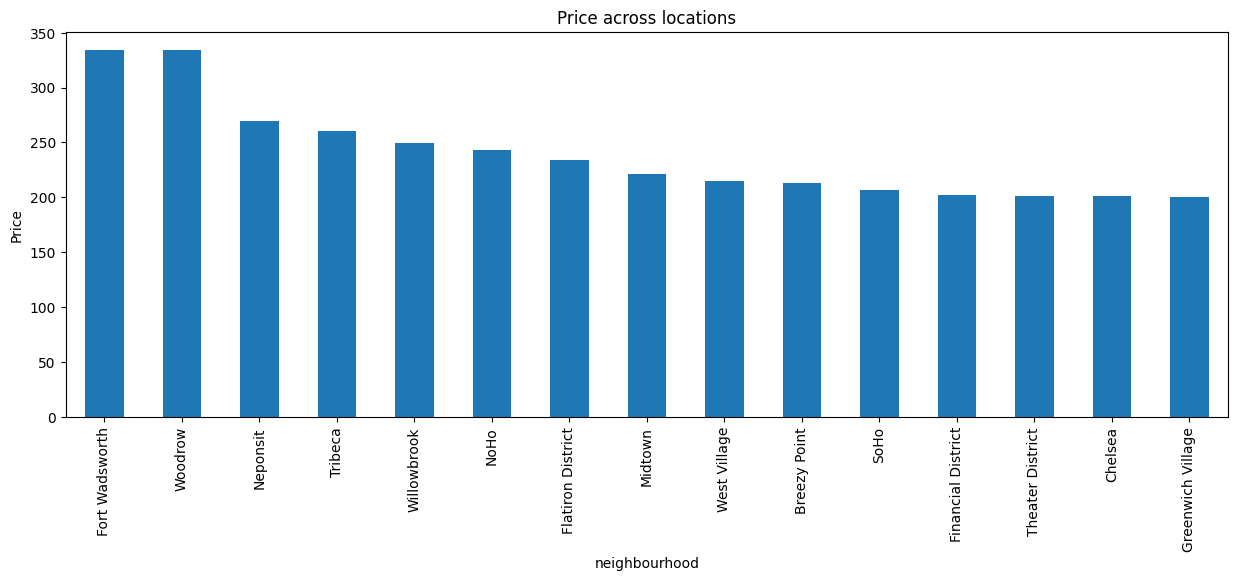

In [20]:
plt.figure(figsize= (15,5))
price_across_locations = df.groupby("neighbourhood")["price"].mean().nlargest(15)
print(price_across_locations, '\n')

price_across_locations.plot(kind='bar')
plt.title('Price across locations')
plt.xticks(rotation= 90)
plt.ylabel('Price')
plt.show()

### Conclusion:
* Fort Wadsworth and Woodrow (both in Staten Island) surprisingly leads, likely due to a very small number of premium or unique listings inflating the average rather than high overall demand
* Tribeca and NoHo command premium Manhattan prices, consistent with their status as some of NYC's most upscale and sought-after neighbourhoods
* Willowbrook is another Staten Island outlier, again suggesting that sparse, high-end listings in low-supply areas skew averages upward
* Well-known Manhattan hotspots cluster around — Flatiron, Midtown, West Village, SoHo, Financial District, Chelsea, and Greenwich Village all fall in a tight 200–233 range, reflecting consistent premium demand across central Manhattan
* Relatively narrow price band for the bottom 10 — most neighbourhoods in this top-15 list fall within a 200–244 range, suggesting a natural pricing ceiling for most premium NYC locations
* While Manhattan neighbourhoods dominate due to consistent high demand, niche outer-borough areas with limited listings can exceed even top Manhattan prices, making neighbourhood-level granularity a critical feature for accurate price prediction

## Identify the impact of ratings and reviews on pricing

In [21]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,days_since_last_review
count,4.888400e+04,4.888400e+04,48884.000000,48884.000000,48884.000000,48884.000000,48884.000000,48884,48884.000000,48884.000000,48884.000000,48884.000000
mean,1.901679e+07,6.762203e+07,40.728953,-73.952176,133.009676,7.029887,23.271991,2017-03-18 05:35:31.249488640,1.090800,7.144628,112.779498,834.766999
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,10.000000,1.000000,0.000000,2011-03-28 00:00:00,0.000000,1.000000,0.000000,-7.000000
25%,9.470548e+06,7.817310e+06,40.690100,-73.983080,69.000000,1.000000,1.000000,2016-03-24 00:00:00,0.040000,1.000000,0.000000,12.000000
50%,1.967574e+07,3.079257e+07,40.723080,-73.955685,106.000000,3.000000,5.000000,2019-01-03 00:00:00,0.370000,1.000000,45.000000,179.000000
75%,2.915297e+07,1.074344e+08,40.763120,-73.936290,175.000000,5.000000,24.000000,2019-06-19 00:00:00,1.580000,2.000000,227.000000,1194.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,334.000000,1250.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000,3017.000000
std,1.098432e+07,7.861666e+07,0.054532,0.046159,83.516076,20.512224,44.551331,NaN,1.597213,32.956185,131.627271,1169.920057


reviews_per_month
0.00     148.812655
0.01     152.690476
0.02     122.760609
0.03     124.177861
0.04     124.001527
            ...    
17.82     50.000000
19.75     80.000000
20.94     45.000000
27.95    199.000000
58.50    100.000000
Name: price, Length: 938, dtype: float64 



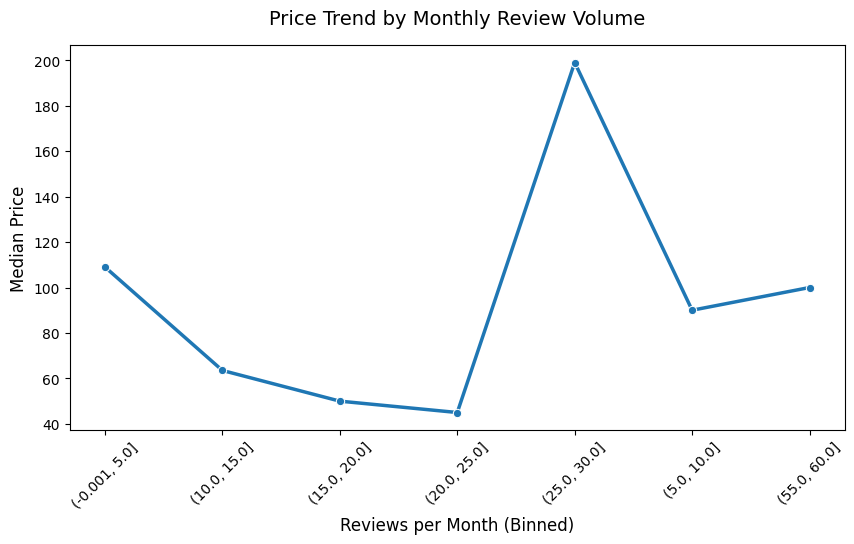

In [22]:
price_vs_ratings = df.groupby("reviews_per_month")["price"].mean()
print(price_vs_ratings, '\n')

# Create bins of size 5 for reviews_per_month (from 0 to 60)
bins = list(range(0, 65, 5))

# Create a temporary column for the bins
df['review_bins'] = pd.cut(df['reviews_per_month'], bins=bins, include_lowest=True)
df['review_bins'] = df['review_bins'].astype(str)

binned_df = df.groupby('review_bins', observed=False)['price'].median().reset_index()


plt.figure(figsize=(10, 5))
sns.lineplot(data=binned_df, x='review_bins', y='price', marker='o', linewidth=2.5)

plt.title('Price Trend by Monthly Review Volume', fontsize=14, pad=15)
plt.xlabel('Reviews per Month (Binned)', fontsize=12)
plt.ylabel('Median Price', fontsize=12)

plt.xticks(rotation=45)
plt.show()

### Conclusion:
* The relationship is non-linear. For the vast majority of the data, higher review frequency correlates with a lower, more budget-friendly price
* However, the massive spike at 25–30 reviews reveals a highly successful "sweet spot" where select high-end properties achieve maximum engagement without sacrificing premium pricing

## Converting categorical features into numerical representations

In [23]:
df.head()

,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,days_since_last_review,response_band,review_bins
0,2539,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149.0,1,9,2018-10-19,0.21,6,365,255,6–12 months,"(-0.001, 5.0]"
1,2595,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225.0,1,45,2019-05-21,0.38,2,355,41,1–3 months,"(-0.001, 5.0]"
2,3647,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150.0,3,0,2011-03-28,0.00,1,365,3017,> 1 year,"(-0.001, 5.0]"
3,3831,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89.0,1,270,2019-07-05,4.64,1,194,-4,NaN,"(-0.001, 5.0]"
4,5022,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80.0,10,9,2018-11-19,0.10,1,0,224,6–12 months,"(-0.001, 5.0]"


In [24]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols

['neighbourhood_group', 'neighbourhood', 'room_type', 'review_bins']

# Feature Selection:

In [25]:
# Encoding the Categorical/labelled data into numerical using Label Encoder
le = LabelEncoder()

df['neighbourhood_group'] = le.fit_transform(df['neighbourhood_group'])
df['neighbourhood'] = le.fit_transform(df['neighbourhood'])
df['room_type'] = le.fit_transform(df['room_type'])

In [26]:
x = df.drop(['id', 'host_id', 'last_review', 'days_since_last_review', 'response_band', 'review_bins', 'price'], axis=1)
y = df['price']

In [27]:
print(y.describe())
print(y[y > y.quantile(0.90)])  

count    48884.000000
mean       133.009676
std         83.516076
min         10.000000
25%         69.000000
50%        106.000000
75%        175.000000
max        334.000000
Name: price, dtype: float64
20       299.0
61       334.0
68       275.0
82       285.0
85       334.0
         ...  
48758    334.0
48833    334.0
48839    334.0
48842    334.0
48856    334.0
Name: price, Length: 4878, dtype: float64


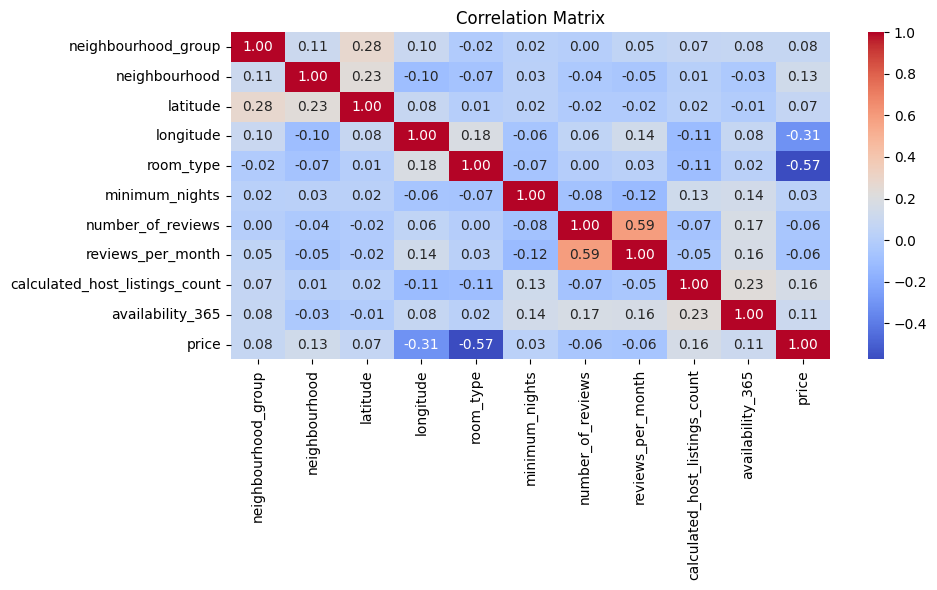

Correlation with price:
 price                             1.000000
room_type                         0.574388
longitude                         0.311697
calculated_host_listings_count    0.162581
neighbourhood                     0.133776
availability_365                  0.112792
neighbourhood_group               0.082073
latitude                          0.073768
reviews_per_month                 0.061938
number_of_reviews                 0.057611
minimum_nights                    0.034134
Name: price, dtype: float64

 Selected by Correlation: ['room_type', 'longitude', 'calculated_host_listings_count', 'neighbourhood', 'availability_365', 'neighbourhood_group', 'latitude', 'reviews_per_month', 'number_of_reviews']


In [28]:
plt.figure(figsize=(10, 6))
corr = x.copy()
corr['price'] = y
sns.heatmap(corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Drop features with low correlation to target
correlation_with_target = corr.corr()['price'].abs().sort_values(ascending=False)
print("Correlation with price:\n", correlation_with_target)

selected_corr = correlation_with_target[correlation_with_target > 0.05].index.tolist()
selected_corr.remove('price')
print("\n Selected by Correlation:", selected_corr)


Random Forest Feature Importances:
 room_type                         0.349688
longitude                         0.188208
latitude                          0.148945
availability_365                  0.082324
reviews_per_month                 0.060747
minimum_nights                    0.053196
number_of_reviews                 0.051370
neighbourhood                     0.032214
calculated_host_listings_count    0.031206
neighbourhood_group               0.002101
dtype: float64


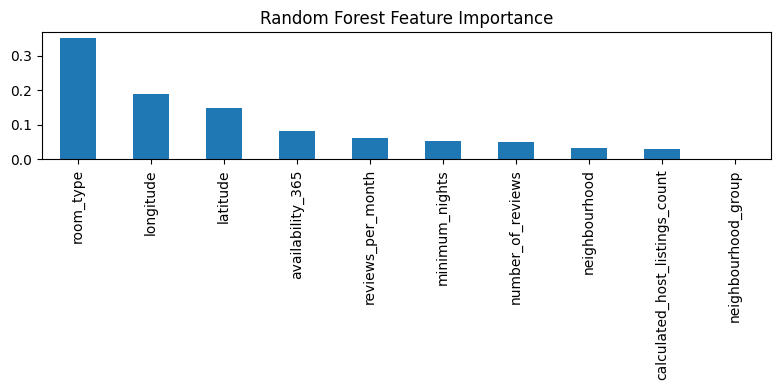

Selected by RF Importance: ['room_type', 'longitude', 'latitude']


In [29]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x, y)

importances = pd.Series(rf.feature_importances_, index=x.columns).sort_values(ascending=False)
print("\nRandom Forest Feature Importances:\n", importances)

importances.plot(kind='bar', title='Random Forest Feature Importance', figsize=(8, 4))
plt.tight_layout()
plt.show()

# Select features above mean importance
selected_rf = importances[importances > importances.mean()].index.tolist()
print("Selected by RF Importance:", selected_rf)

In [30]:
all_selected = selected_corr + selected_rf

vote_count = pd.Series(all_selected).value_counts()
print("\nFeature Vote Count (across all methods):\n", vote_count)

# Features selected by at least 2 methods
final_features = vote_count[vote_count >= 1].index.tolist()
print("\n✅ Final Selected Features:", final_features)

x_final = x[final_features]
print("\nFinal Feature Shape:", x_final.shape)


Feature Vote Count (across all methods):
 room_type                         2
longitude                         2
latitude                          2
neighbourhood                     1
calculated_host_listings_count    1
availability_365                  1
neighbourhood_group               1
reviews_per_month                 1
number_of_reviews                 1
Name: count, dtype: int64

✅ Final Selected Features: ['room_type', 'longitude', 'latitude', 'neighbourhood', 'calculated_host_listings_count', 'availability_365', 'neighbourhood_group', 'reviews_per_month', 'number_of_reviews']

Final Feature Shape: (48884, 9)


In [31]:
x_train, x_test, y_train, y_test = train_test_split(x_final, y, test_size= 0.2, random_state= 42)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(39107, 9)
(9777, 9)
(39107,)
(9777,)


In [32]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)   # fit only on train
x_test_scaled  = scaler.transform(x_test)

x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled  = pd.DataFrame(x_test_scaled,  columns=x_test.columns)

In [33]:
#Prepare a Linear Regression Model
reg=LinearRegression()
reg.fit(x_train_scaled,y_train)
y_pred=reg.predict(x_test_scaled)
r2_score(y_test,y_pred)

0.40547939550307877

In [34]:
#Prepairng a Decision Tree Regression

DTree=DecisionTreeRegressor(min_samples_leaf=.0001)
DTree.fit(x_train_scaled,y_train)
y_predict=DTree.predict(x_test_scaled)
r2_score(y_test,y_predict)

0.3536017947450889

In [35]:
xgbreg = XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=5, min_child_weight=1)
xgbreg.fit(x_train_scaled, y_train) 
y_train_pred = xgbreg.predict(x_train_scaled)
y_test_pred = xgbreg.predict(x_test_scaled)
print('training error:', [mean_squared_error(y_train, y_train_pred)])
print('test error:', [mean_squared_error(y_test, y_test_pred)])
print('training_r2_score:', [r2_score(y_train, y_train_pred)])
print('test_r2_score:', [r2_score(y_test, y_test_pred)])

training error: [2313.4099477698105]
test error: [3103.0881701666585]
training_r2_score: [0.6676065151490929]
test_r2_score: [0.5588786563985648]


# Conclusion:

## Pricing recommendations for hosts:
1. Location is your strongest lever
* Neighbourhood group and neighbourhood rank as top features in the Random Forest
* Manhattan listings command ~60% more than the city average
* * Highlight proximity to transit, landmarks, and Manhattan in your listing title and description — location signals justify a higher price floor
  * Outer boroughs — Compensate with amenities and high review velocity to close the gap against better-located listings

2. Room type sets your price ceiling
* Entire home/apt listings price more than 2× higher than private rooms
* The gap between private and shared rooms is only ~$20
* * If you can offer full-home access, do it — it's the single biggest categorical price jump in the dataset
  * Upgrade from shared to private if possible. The revenue bump far exceeds the modest incremental cost to the guest

3. Review recency drives booking demand
* Listings reviewed within the last month show significantly higher engagement and pricing power than those reviewed 6+ months ago
* * Ask every guest for a review immediately after checkout. Fresh reviews act as a demand signal that the model (and Airbnb's algorithm) rewards
  * Letting your listing go 3–6 months without a review causes a measurable drop in booking rate and pricing leverage
  * Listings in the < 1 month band have the highest reviews_per_month and book at stronger prices

4. Availability sweet spot
* High availability_365 (near 365) correlates with professional hosts who price efficiently
* Keep your calendar open — idle nights are lost revenue. Aim for > 300 open days unless you need them

5. Minimum nights strategy
* Most competitive listings use minimum_nights = 1–3. Very high minimums (10+) shrink your potential guest pool
* Reserve long minimums only for slow seasons to reduce vacancy